<a href="https://colab.research.google.com/github/Rahmi1635/MachineLearningExamples/blob/main/lineer_regresyon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets,linear_model
from sklearn.metrics import mean_absolute_error,r2_score
from mpl_toolkits.mplot3d import Axes3D # 3D grafik için

In [20]:
#1 - Veri Setini Yükleme İşlemi
diabetes_X_raw,diabetes_y=datasets.load_diabetes(return_X_y=True)

In [21]:
#2 - iki özellik seçimi BMI VE KAN BASINCI

diabetes_X_multi=diabetes_X_raw[:,[2,3]]

In [36]:
#3 - Veriyi Eğitim ve Test olarak ayırma
X_train_multi=diabetes_X_multi[:-20]
X_test_multi=diabetes_X_multi[-20:]
y_train=diabetes_y[:-20]
y_test=diabetes_y[-20:]


In [26]:
#4 - Modeli Eğitme İşlemi
regr_multi=linear_model.LinearRegression()
regr_multi.fit(X_train_multi,y_train)
y_pred=regr_multi.predict(X_test_multi)

In [27]:
#5 - Sonuçları Hesaplama
mae_multi=mean_absolute_error(y_test,y_pred)
r2_multi=r2_score(y_test,y_pred)
print("--- 2 Özellikli (BMI + Kan Basıncı) Sonuçlar ---")
print(f"Ortalama Mutlak Hata (MAE): {mae_multi:.2f}")
print(f"R-Kare Skoru (R2): {r2_multi:.2f}")
print(f"Model Katsayıları (Eğimler): {regr_multi.coef_}") # İki tane katsayı verecek
print(f"Model Sabiti (Kesişim): {regr_multi.intercept_}")

--- 2 Özellikli (BMI + Kan Basıncı) Sonuçlar ---
Ortalama Mutlak Hata (MAE): 40.90
R-Kare Skoru (R2): 0.47
Model Katsayıları (Eğimler): [781.17242861 410.14389103]
Model Sabiti (Kesişim): 152.86283988723363


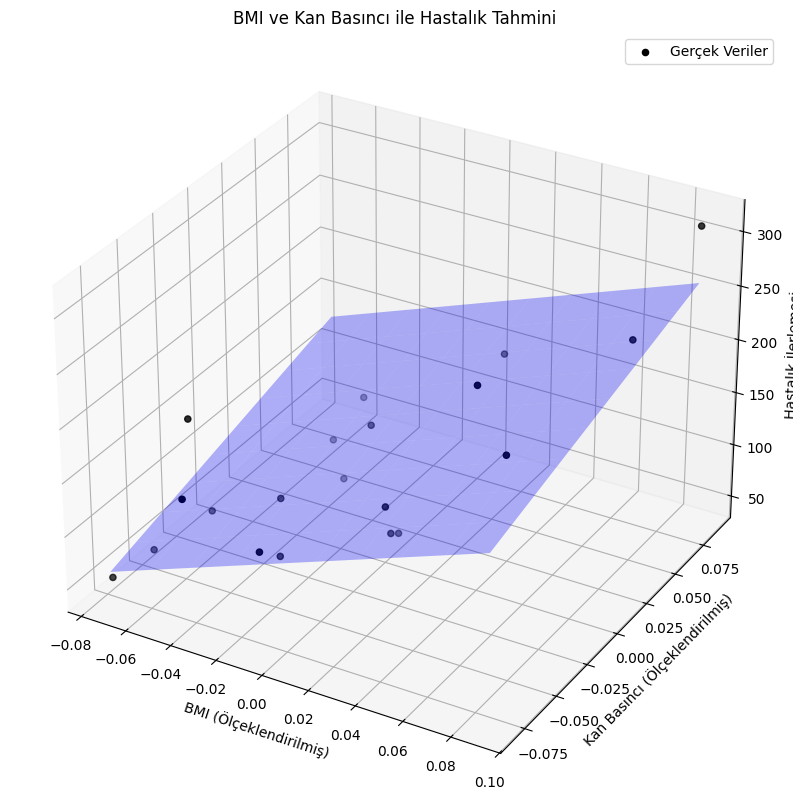

In [37]:
# --- 6. Görselleştirme (3D Grafik) ---
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Gerçek verileri çiz (Siyah noktalar)
ax.scatter(X_test_multi[:, 0], X_test_multi[:, 1], y_test, color='black', label='Gerçek Veriler')

# Modelin tahminlerini çiz (Kırmızı noktalar)
# ax.scatter(X_test_multi[:, 0], X_test_multi[:, 1], y_pred_multi, color='red', marker='x', label='Tahminler')

# Tahmin Düzlemini Çizmek
x_grid, y_grid = np.meshgrid(np.linspace(X_test_multi[:, 0].min(), X_test_multi[:, 0].max(), 10),
                             np.linspace(X_test_multi[:, 1].min(), X_test_multi[:, 1].max(), 10))
z_grid = regr_multi.intercept_ + regr_multi.coef_[0] * x_grid + regr_multi.coef_[1] * y_grid
ax.plot_surface(x_grid, y_grid, z_grid, color='blue', alpha=0.3) # Yarı saydam tahmin düzlemi

# Eksen Etiketleri
ax.set_xlabel('BMI (Ölçeklendirilmiş)')
ax.set_ylabel('Kan Basıncı (Ölçeklendirilmiş)')
ax.set_zlabel('Hastalık İlerlemesi')
ax.set_title('BMI ve Kan Basıncı ile Hastalık Tahmini')
plt.legend()
plt.show()